Import Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



Load Dataset

In [44]:
df = sns.load_dataset("titanic")


3 ) find head and tail 

In [45]:
df.head()
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


 Basic Data Understanding (EDA)

In [46]:
df.head()
df.info()
df.describe()
df.isnull()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


 find the total number of null values each columns


In [47]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival Analysis

In [80]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Passenger Class Analysis

In [84]:
pd.crosstab(df['pclass'], df['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


Age Analysis

<Axes: xlabel='age', ylabel='Count'>

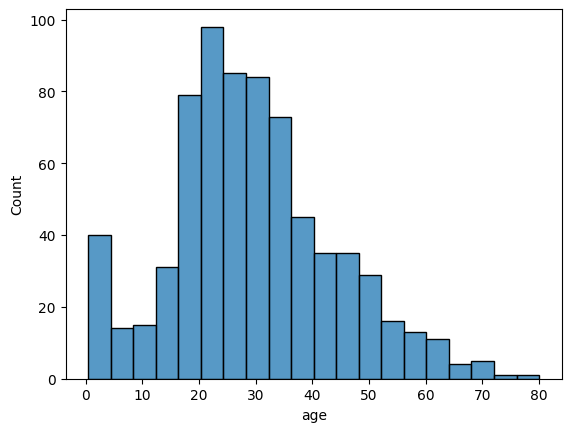

In [85]:
sns.histplot(df['age'], bins=20)

Fare Analysis

✔ Fare distribution
✔ Fare vs Pclass
✔ Fare vs Survival

Text(0, 0.5, 'Frequency')

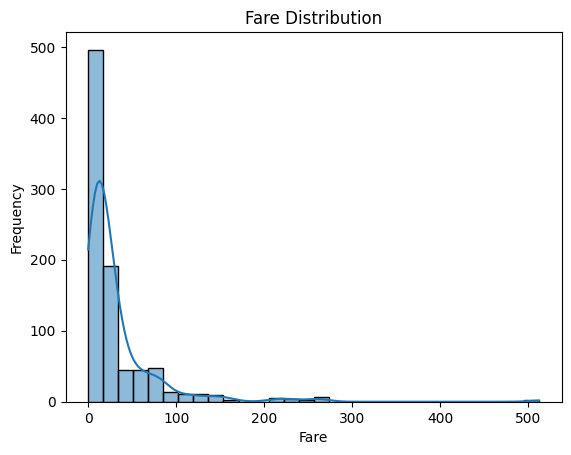

In [86]:
sns.histplot(df['fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

Text(0, 0.5, 'Fare')

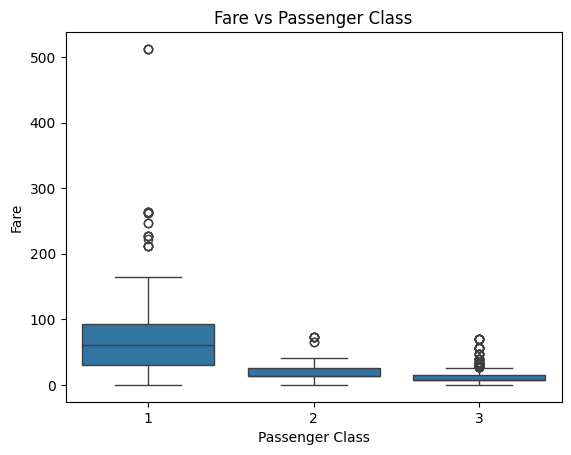

In [87]:
sns.boxplot(x='pclass', y='fare', data=df)
plt.title("Fare vs Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

Text(0.5, 1.0, 'Fare by Class and Survival')

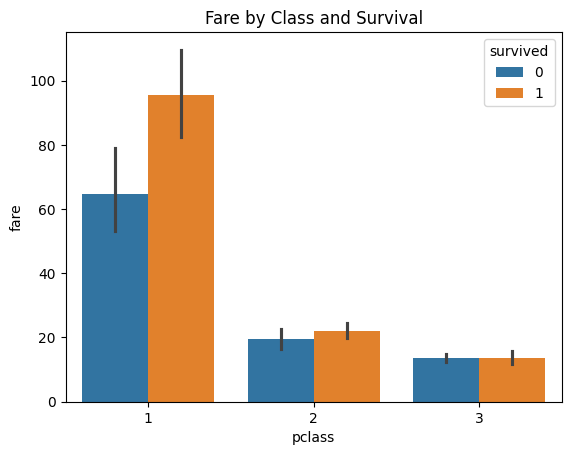

In [88]:
sns.barplot(x='pclass', y='fare', hue='survived', data=df)
plt.title("Fare by Class and Survival")

Correlation (Important)

<Axes: >

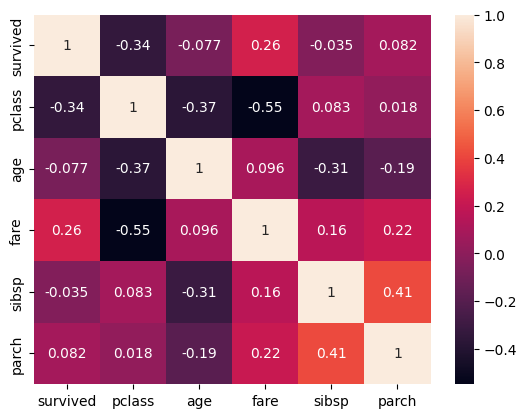

In [90]:
numeric_df = df[['survived', 'pclass', 'age', 'fare', 'sibsp', 'parch']]
sns.heatmap(numeric_df.corr(), annot=True)

Gender Analysis

<Axes: xlabel='sex', ylabel='count'>

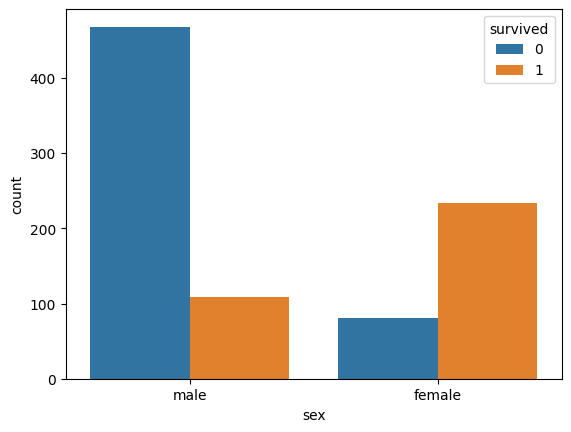

In [83]:
sns.countplot(x='sex', hue='survived', data=df)

 Visualization Ideas:

<Axes: xlabel='survived', ylabel='count'>

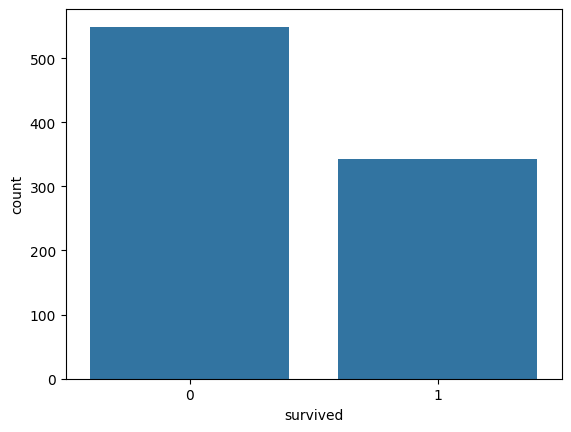

In [48]:
# survival bar plot
sns.countplot(x="survived", data=df)

<Axes: xlabel='pclass', ylabel='count'>

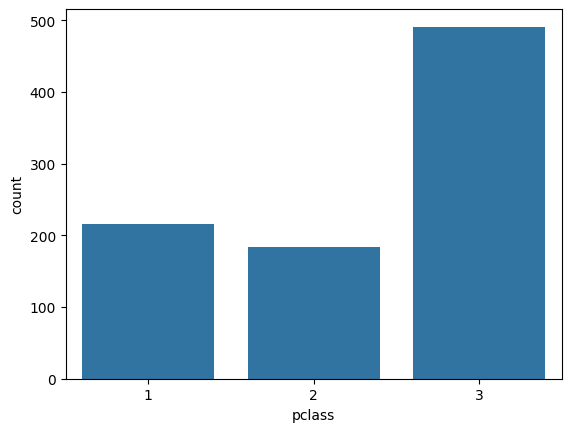

In [49]:
# pclass bar plot
sns.countplot(x="pclass", data =df)


<Axes: xlabel='sex', ylabel='count'>

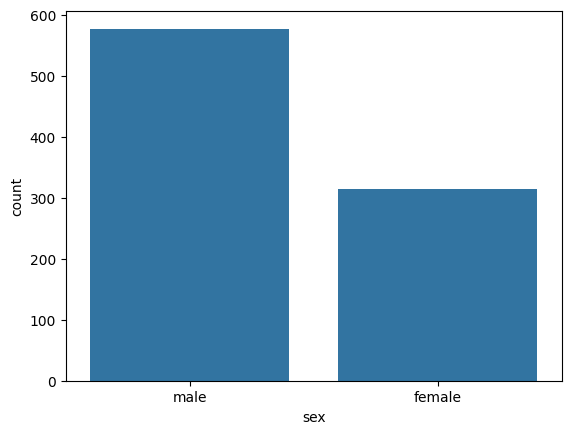

In [50]:
# sex bar plot
sns.countplot(x="sex", data =df)



<Axes: xlabel='age', ylabel='Count'>

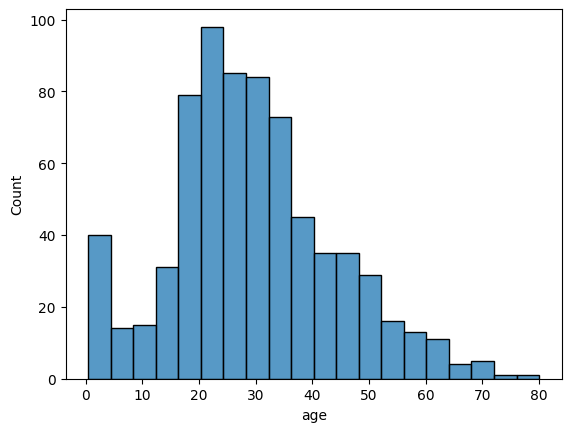

In [51]:
# age histogram
sns.histplot(x="age", data =df)

“Cross Tabulation of Survival by PClass”

In [55]:

x=pd.crosstab(df["pclass"],df["survived"])


C:\Users\DELL\AppData\Local\Temp\ipykernel_16336\2640184092.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  x1=x.div(x.sum(1).astype(float), axis=0)


Text(0, 0.5, 'survival rate')

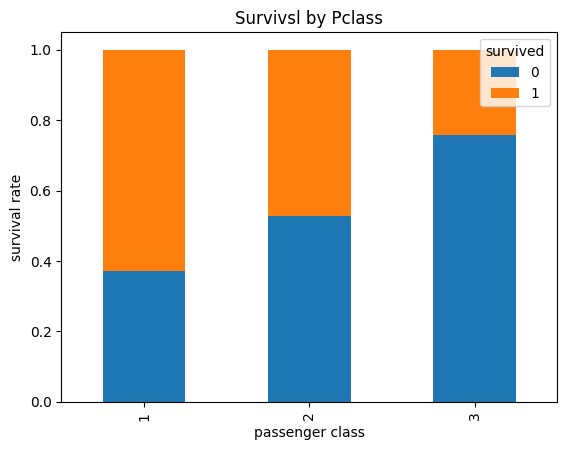

In [57]:
x1=x.div(x.sum(1).astype(float), axis=0)
x1.plot(kind="bar", stacked=True ,title="Survivsl by Pclass")
plt.xlabel("passenger class")
plt.ylabel("survival rate")

“Feature Engineering: Encoding the Gender Variable”


In [61]:
#Unique gender values
sexes = sorted(df['sex'].unique())
#Gender mapping
genders_mapping = dict(zip(sexes, range(0, len(sexes)+1)))
#Mapping apply
df['Sex_Val'] = df['sex'].map(genders_mapping).astype(int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Sex Val,Sex_Val
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,1


“Cross Tabulation of Survival by Sex Val


C:\Users\DELL\AppData\Local\Temp\ipykernel_16336\970481386.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  x1=x.div(x.sum(1).astype(float), axis=0)


Text(0.5, 0, 'Sex Val')

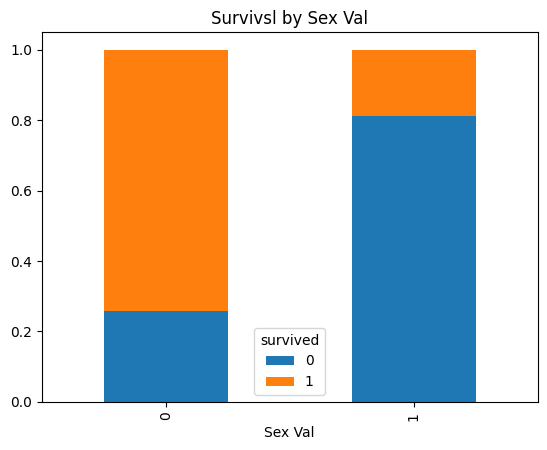

In [64]:
x=pd.crosstab(df["Sex_Val"],df["survived"])
x1=x.div(x.sum(1).astype(float), axis=0)
x1.plot(kind="bar", stacked=True ,title="Survivsl by Sex Val")
plt.xlabel("Sex Val")


“Count of Male and Female Passengers by Passenger Class”

In [72]:
#Unique Passenger class values
passenger_class = sorted(df['pclass'].unique())
#Loop       
for p_class in passenger_class:
    print('M- ', p_class, 
          len(df[(df['sex'] == 'male') & 
                 (df['pclass'] == p_class)]))

    print('F- ', p_class, 
          len(df[(df['sex'] == 'female') & 
                 (df['pclass'] == p_class)]))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

M-  1 122
F-  1 94
M-  2 108
F-  2 76
M-  3 347
F-  3 144


Females Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_16336\3151494972.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  females_per = females_x.div(females_x.sum(1).astype(float), axis=0)


<Axes: title={'center': 'Survival rate of females by passenger class'}, xlabel='pclass'>

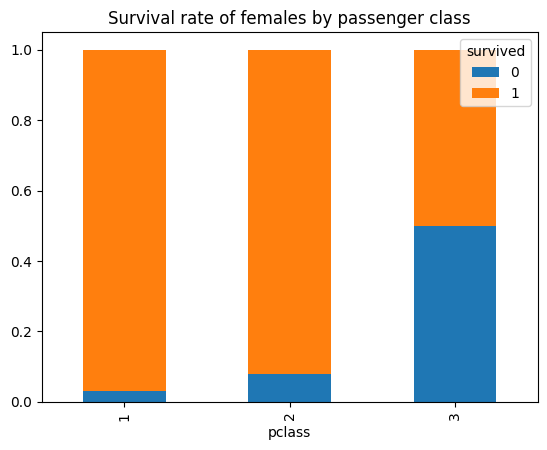

In [78]:
females= df[df['sex'] == 'female']
females_x = pd.crosstab(females['pclass'], df['survived'])
females_per = females_x.div(females_x.sum(1).astype(float), axis=0)

females_per.plot(kind='bar',
                    stacked='True',
                    title='Survival rate of females by passenger class')

Males Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_16336\3015662599.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  males_per = males_x.div(males_x.sum(1).astype(float), axis=0)


<Axes: title={'center': 'Survival rate of males by passenger class'}, xlabel='pclass'>

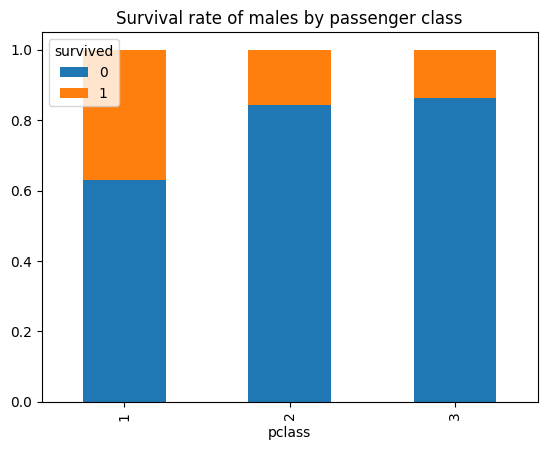

In [79]:
males= df[df['sex'] == 'male']
males_x = pd.crosstab(males['pclass'], df['survived'])
males_per = males_x.div(males_x.sum(1).astype(float), axis=0)

males_per.plot(kind='bar',
                    stacked='True',
                    title='Survival rate of males by passenger class')